### Analysis and collection of data

This manip is about data preparation and exploratory data analysis (EDA). The goal is to clean and transform the Titanic dataset so it’s ready for machine learning. Here’s what you’ll do:

Load the dataset and explore it.
Clean the data: Handle missing values, remove duplicates, and deal with outliers.
Transform the data: Encode categorical variables (like sex and embarked) into numbers, and scale numerical variables.
Reduce the number of features using Principal Component Analysis (PCA).
Visualize the data to understand relationships between variables.


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#The Titanic dataset is available in the seaborn library, which is a popular Python library for data visualization.
titanic = sns.load_dataset('titanic')
# Display the first few rows of the dataset
titanic.head()
# Display general information about the dataset(datatypes)
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Count missing values per column
missing_values = titanic.isnull().sum()
print(missing_values)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


 #### preprocessing, more precisely  normalization/scaling of numerical data

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

MinMaxScaler: Normalizes data to a range of [0, 1].
StandardScaler: Standardizes data to have a mean of 0 and a standard deviation of 1.

In [12]:
trans_MM = MinMaxScaler()
trans_SS = StandardScaler()
X = titanic.drop(['survived'], axis=1)


In [ ]:
df_MM = trans_MM.fit_transform(X)#Apprend les paramètres et transforme les données en une seule étape
pd.DataFrame(df_MM)# Convertit le résultat (tableau NumPy) en DataFrame pour une manipulation plus facile.

,0,1
0,0.0,0.0
1,0.5,0.5
2,1.0,1.0


In [9]:
df_SS = trans_SS.fit_transform(X)
pd.DataFrame(df_SS)#, on crée un nouveau DataFrame à partir du tableau NumPy df_SS.

,0,1
0,-1.224745,-1.224745
1,0.000000,0.000000
2,1.224745,1.224745


### Data cleaning

In [16]:
# Imputation par la médiane
titanic['age'].fillna(titanic['age'].median(), inplace=True)
print(f"\nValeurs manquantes après: {titanic['age'].isnull().sum()}")


Valeurs manquantes après: 0


/tmp/ipython-input-3265194885.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)


In [17]:
# Calcul du mode (valeur la plus fréquente)
mode_embarked = titanic['embarked'].mode()[0]
print(f"\nMode (port le plus fréquent): {mode_embarked}")


Mode (port le plus fréquent): S


In [18]:
# Imputation par le mode
titanic['embarked'].fillna(mode_embarked, inplace=True)
print(f"Valeurs manquantes après: {titanic['embarked'].isnull().sum()}")

Valeurs manquantes après: 0


/tmp/ipython-input-2860761207.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['embarked'].fillna(mode_embarked, inplace=True)


In [21]:
print(f"colonnes: {titanic.columns.tolist()}")


colonnes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [19]:
# Suppression de la colonne
titanic.drop('deck', axis=1, inplace=True)

In [20]:
print(f"Nouvelles colonnes: {titanic.columns.tolist()}")


Nouvelles colonnes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [22]:
print(f"Nombre de lignes dupliquées: {titanic.duplicated().sum()}")


Nombre de lignes dupliquées: 116


In [25]:
tt = titanic.duplicated().sum()
print(f"Nombre de lignes dupliquées: {tt}")


Nombre de lignes dupliquées: 116


In [26]:
# SUPPRIMER DIRECTEMENT les doublons (méthode la plus simple)
titanic = titanic.drop_duplicates()

# Vérifier APRÈS suppression
print(f"Doublons après: {titanic.duplicated().sum()}")

Doublons après: 0



--- ANALYSE DES OUTLIERS DE FARE ---


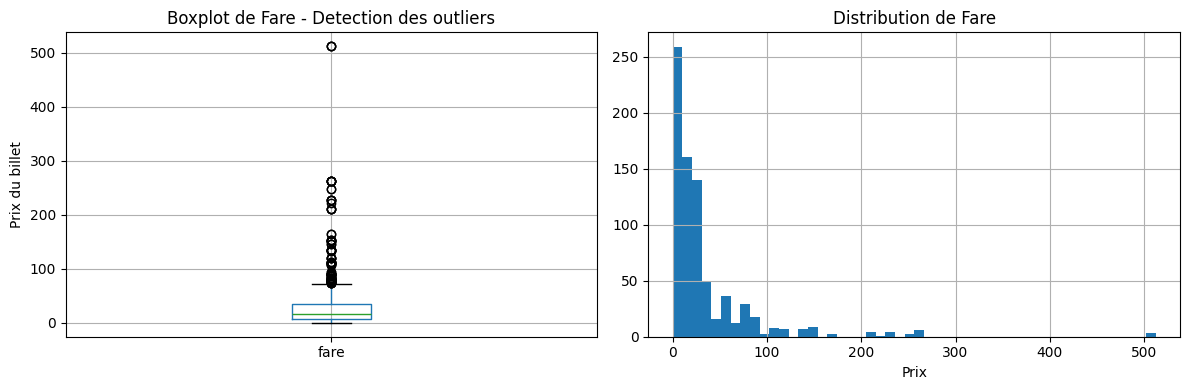

Statistiques de base:
count    775.000000
mean      34.878403
std       52.408474
min        0.000000
25%        8.050000
50%       15.900000
75%       34.197900
max      512.329200
Name: fare, dtype: float64


In [27]:
print("\n--- ANALYSE DES OUTLIERS DE FARE ---")

# Boxplot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
titanic.boxplot(column='fare')
plt.title('Boxplot de Fare - Detection des outliers')
plt.ylabel('Prix du billet')

plt.subplot(1, 2, 2)
titanic['fare'].hist(bins=50)
plt.title('Distribution de Fare')
plt.xlabel('Prix')
plt.tight_layout()
plt.show()

print("Statistiques de base:")
print(titanic['fare'].describe())